# 05 — La componente longitudinal $|E_z|^2$ en el lóbulo central

Los cuadernos 01–04 midieron el lóbulo con la intensidad **transversal**
$|E_x|^2+|E_y|^2$. Pero un campo enfocado no es transversal: la condición
$\mathbf{k}\cdot\mathbf{E}=0$ de Maxwell genera una componente $E_z$ que
crece con el ángulo de enfoque y que, en el régimen de Richards y Wolf
[Proc. R. Soc. A **253**, 358 (1959)], llega a **invertir** la dirección de
elongación del lóbulo. Este cuaderno la incorpora al análisis con el mismo
método del paquete (`vecdiff.longitudinal`) pero en forma **radial cerrada**.

## Reducción analítica del canal longitudinal

Cada anillo de pupila $r$ aporta al espectro angular la frecuencia
transversal $k_t = k\,r/z_i$ (con $k = 2\pi n_i/\lambda$ en el medio
imagen), es decir $\sin\theta = r/z_i$ y
$k_z = k\sqrt{1-(r/z_i)^2}$. La transversalidad
$E_z = -\,(k_t/k_z)\,E_p$ solo involucra la componente **p** (radial en la
pupila), que para polarización lineal homogénea vale $t_p P\cos(\varphi-\alpha)$.
El factor angular $\cos(\varphi-\alpha)$ selecciona el canal $m=1$:

$$ E_z(\rho,\varphi) \;=\; -\,2\pi i\,H_z(\rho)\,\cos(\varphi-\alpha),
   \qquad H_z = \mathcal{H}_1\!\big[w_z\,t_p\,P\big],
   \qquad w_z(r) = \frac{r/z_i}{\sqrt{1-(r/z_i)^2}}. $$

Sumando $|E_z|^2 = 2\pi^2\,|H_z|^2\,[1+\cos 2(\varphi-\alpha)]$ a la
intensidad transversal del cuaderno 01, la intensidad total queda, en las
cantidades del problema,

$$ I_{\rm tot}/\pi^2 \;=\; |H_0|^2 + |H_2|^2 + 2\,|H_z|^2
   \;-\; 2\,\big[\mathrm{Re}(H_0H_2^*) - |H_z|^2\big]\cos 2(\varphi-\alpha). $$

Conviene abreviar $A = |H_0|^2+|H_2|^2$ (fondo simétrico),
$B = \mathrm{Re}(H_0H_2^*)$ (interferencia co–cruzada) y $Z = |H_z|^2$
(perfil longitudinal):

$$ I_{\rm tot}/\pi^2 \;=\; A + 2Z \;-\; 2\,(B - Z)\cos 2(\varphi-\alpha). $$

Consecuencias inmediatas:

- **El corte perpendicular no cambia**: $I_\perp^{\rm tot} = |H_0+H_2|^2$
  ($E_z\propto\cos(\varphi-\alpha)$ se anula en $\varphi-\alpha=\pm\pi/2$).
- **El corte paralelo gana $4Z$**: $I_\parallel^{\rm tot} = |H_0-H_2|^2+4Z$;
  $E_z$ ensancha el lóbulo *a lo largo* de la polarización, oponiéndose a la
  contracción del canal cruzado.
- El predictor local del cuaderno 03 se extiende sin esfuerzo:
  $\;A_{\rm tot} \simeq 4\,[B(R_{\rm sca})-Z(R_{\rm sca})]\,/\,(|I'_{\rm sca}|R_{\rm sca})$.
  La elongación **se invierte exactamente donde $Z$ supera a $B$** en el
  radio de mitad de altura.
- Incidencia circular: $I \propto A + 2Z$, sigue simétrica.
- Energía del canal (Parseval, $m=1$):
  $e_z = 2\!\int |w_z\,t_p P|^2\,r\,dr$, con fracción
  $f_z = e_z/(e_0+e_2+e_z)$.

Dos palancas distintas controlan las dos correcciones vectoriales: $f_z$
crece con el **ángulo de enfoque** ($\sin\theta_{\max}=a/z_i$), mientras que
$f_{\rm cross}$ crece con el **salto de índice** (anisotropía de Fresnel,
cuadernos 02 y 04).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spot_tools as st

out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

# Los dos dioptrios de cabecera: vidrio base y el rápido de alto índice.
case_g = st.spot_case(n0=1.0, ni=1.5, z0=-10.0, zi=6.0, lam=532e-6, a_frac=0.97)
case_h = st.spot_case(n0=1.0, ni=2.4, z0=-2.0, zi=6.0, lam=532e-6, a_frac=0.97)
for label, cs in [("vidrio base ", case_g), ("rápido ni=2.4", case_h)]:
    sin_th = cs["a"] / 6.0
    print(f"{label}: a = {cs['a']:.3f} mm,  sin θ_max = a/zi = {sin_th:.3f} "
          f"(θ = {np.degrees(np.arcsin(sin_th)):.1f}°)")

vidrio base : a = 3.646 mm,  sin θ_max = a/zi = 0.608 (θ = 37.4°)
rápido ni=2.4: a = 3.033 mm,  sin θ_max = a/zi = 0.506 (θ = 30.4°)


## Validación contra la tubería del paquete

`vecdiff.longitudinal.generate_Ez_cartesian` construye $E_z$ por espectro
angular (FFT del campo transversal reconstruido, $E_Z=-(k_xE_X+k_yE_Y)/k_z$).
Comparamos el mapa $|E_z|^2$ de la fórmula radial contra esa tubería para
ambos dioptrios, con $\alpha=30°$. La malla radial se extiende a
$s_{\max}=12\lambda$ para cubrir la ventana FFT.

In [2]:
from vecdiff.field_reconstruction import hankel_terms, reconstruct_2d_from_terms
from vecdiff.longitudinal import generate_Ez_cartesian

alpha = np.radians(30.0)
half, n_fft = 8.0, 1024
x_fft = np.linspace(-half, half, n_fft)
xx, yy = np.meshgrid(x_fft, x_fft)
rho, varphi = np.hypot(xx, yy), np.arctan2(yy, xx)

for label, kw, ni in [("vidrio base ", dict(ni=1.5, z0=-10.0), 1.5),
                      ("rápido ni=2.4", dict(ni=2.4, z0=-2.0), 2.4)]:
    cs = st.spot_case(n0=1.0, zi=6.0, lam=532e-6, a_frac=0.97,
                      s_max=12.0, n_q=2400, **kw)
    terms = hankel_terms(cs["r"], cs["q"], cs["tp"], cs["ts"],
                         e1=np.cos(alpha) * cs["P"], e2=np.sin(alpha) * cs["P"],
                         polarization="cartesian")
    Ex, Ey = reconstruct_2d_from_terms(terms, cs["s"], rho, varphi,
                                       polarization="cartesian")
    # malla en unidades de lambda -> wavelength=1 y n=ni
    Ez_pkg = generate_Ez_cartesian(Ex, Ey, (xx, yy), wavelength=1.0, n=ni)
    Iz_pkg = np.abs(Ez_pkg) ** 2 / np.pi ** 2
    Zr = np.interp(rho, cs["s"], np.abs(cs["Hz"]) ** 2)
    Iz_ana = 2.0 * Zr * (1.0 + np.cos(2.0 * (varphi - alpha)))
    err = np.max(np.abs(Iz_pkg - Iz_ana)[rho < 1.5]) / Iz_ana.max()
    print(f"{label}: máx |I_z(tubería) - I_z(fórmula)| / pico = {err:.2e}")
    assert err < 5e-3  # limitado por la discretización de la FFT

vidrio base : máx |I_z(tubería) - I_z(fórmula)| / pico = 1.55e-03


rápido ni=2.4: máx |I_z(tubería) - I_z(fórmula)| / pico = 6.06e-04


La coincidencia es al nivel de la discretización FFT ($\lesssim 10^{-3}$):
la fórmula radial **es** el método del paquete, en forma cerrada.

## ¿Cuánta energía lleva $E_z$? Dos palancas distintas

La fracción longitudinal $f_z$ (ángulo de enfoque) contra la cruzada
$f_{\rm cross}$ (salto de índice):

In [3]:
rows = []
for label, cs in [("vidrio base", case_g), ("rápido ni=2.4", case_h)]:
    m = st.spot_metrics(cs)
    rows.append((label, m))
    print(f"{label:14s}: f_cross = {m['f_cross']:.4f}   f_z = {m['f_z']:.4f}"
          f"   (f_z/f_cross = {m['f_z'] / m['f_cross']:.1f})")

vidrio base   : f_cross = 0.0043   f_z = 0.0661   (f_z/f_cross = 15.4)
rápido ni=2.4 : f_cross = 0.0259   f_z = 0.0472   (f_z/f_cross = 1.8)


En el vidrio, el canal longitudinal lleva **~15 veces más energía** que el
cruzado: para dioptrios de bajo contraste la corrección vectorial dominante
no es la que estudiamos en 01–04, sino $E_z$. En el dioptrio rápido de alto
índice ambas son comparables ($f_z/f_{\rm cross}\approx 2$).

## Perfiles radiales: dónde $Z$ alcanza a $B$

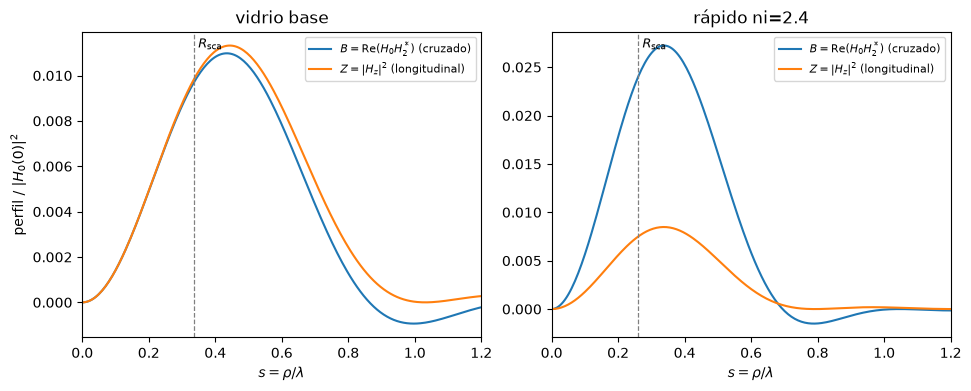

vidrio base   : en R_sca,  Z/B = 1.014  ->  invierte la elongación
rápido ni=2.4 : en R_sca,  Z/B = 0.312  ->  no invierte la elongación


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8), constrained_layout=True)
for ax, (label, cs) in zip(axes, [("vidrio base", case_g), ("rápido ni=2.4", case_h)]):
    s = cs["s"]
    B = np.real(cs["H0"] * np.conj(cs["H2"]))
    Z = np.abs(cs["Hz"]) ** 2
    norm = np.abs(cs["H0"][0]) ** 2
    R_sca = st.hwhm(s, np.abs(cs["H0"]) ** 2)
    ax.plot(s, B / norm, label=r"$B=\mathrm{Re}(H_0H_2^*)$ (cruzado)")
    ax.plot(s, Z / norm, label=r"$Z=|H_z|^2$ (longitudinal)")
    ax.axvline(R_sca, color="gray", ls="--", lw=0.9)
    ax.annotate(r"$R_{\rm sca}$", (R_sca, ax.get_ylim()[1]),
                xytext=(3, -12), textcoords="offset points", fontsize=9)
    ax.set(title=label, xlabel=r"$s = \rho/\lambda$", xlim=(0.0, 1.2))
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"perfil / $|H_0(0)|^2$")
fig.savefig(out_dir / "05_B_vs_Z.png", dpi=200)
plt.show()

for label, cs in [("vidrio base", case_g), ("rápido ni=2.4", case_h)]:
    s = cs["s"]
    R_sca = st.hwhm(s, np.abs(cs["H0"]) ** 2)
    B_R = np.interp(R_sca, s, np.real(cs["H0"] * np.conj(cs["H2"])))
    Z_R = np.interp(R_sca, s, np.abs(cs["Hz"]) ** 2)
    print(f"{label:14s}: en R_sca,  Z/B = {Z_R / B_R:.3f}"
          f"  ->  {'invierte' if Z_R > B_R else 'no invierte'} la elongación")

## Radios principales con y sin $E_z$

Mapas anotados (radios medidos sobre la intensidad, ventana recortada al
lóbulo central): arriba solo transversal, abajo intensidad total.

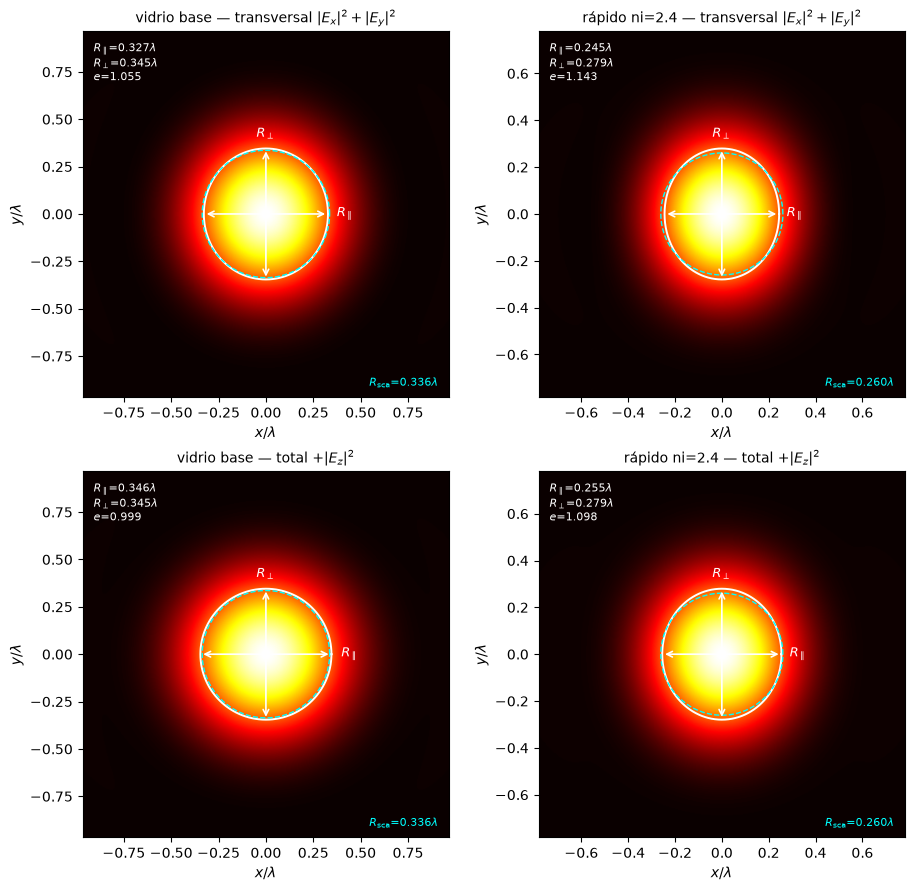

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9.2, 8.8), constrained_layout=True)
for j, (label, cs) in enumerate([("vidrio base", case_g), ("rápido ni=2.4", case_h)]):
    half_size = st.display_half_size(cs)
    _, m = st.plot_spot_with_radii(axes[0, j], cs, half_size=half_size)
    axes[0, j].set_title(f"{label} — transversal $|E_x|^2+|E_y|^2$", fontsize=10)
    _, _ = st.plot_spot_with_radii(axes[1, j], cs, half_size=half_size, total=True)
    axes[1, j].set_title(f"{label} — total $+|E_z|^2$", fontsize=10)
fig.savefig(out_dir / "05_annotated_total.png", dpi=200)
plt.show()

In [6]:
print(f"{'':14s}  {'R_par':>7s} {'R_perp':>7s} {'e':>7s}   "
      f"{'R_par_tot':>9s} {'R_perp_tot':>10s} {'e_tot':>7s}   {'R_circ':>7s} {'R_circ_tot':>10s}")
for label, m in rows:
    print(f"{label:14s}  {m['R_par']:7.4f} {m['R_perp']:7.4f} {m['ellipticity']:7.4f}   "
          f"{m['R_par_tot']:9.4f} {m['R_perp_tot']:10.4f} {m['ellipticity_tot']:7.4f}   "
          f"{m['R_circ']:7.4f} {m['R_circ_tot']:10.4f}")

for label, cs in [("vidrio base", case_g), ("rápido ni=2.4", case_h)]:
    m = st.spot_metrics(cs)
    A_pred = st.anisotropy_prediction(cs, total=True)
    print(f"{label:14s}: A_tot medida = {m['anisotropy_tot']:+.4f}   "
          f"predictor 4(B-Z)/(|I'|R) = {A_pred:+.4f}")

                  R_par  R_perp       e   R_par_tot R_perp_tot   e_tot    R_circ R_circ_tot
vidrio base      0.3275  0.3455  1.0549      0.3458     0.3455  0.9991    0.3362     0.3456
rápido ni=2.4    0.2446  0.2795  1.1426      0.2545     0.2795  1.0981    0.2609     0.2664
vidrio base   : A_tot medida = -0.0009   predictor 4(B-Z)/(|I'|R) = -0.0008
rápido ni=2.4 : A_tot medida = +0.0959   predictor 4(B-Z)/(|I'|R) = +0.0914


- $R_\perp$ **no se mueve** (dígito a dígito), como exige la fórmula.
- En el **vidrio** la cancelación es casi perfecta: $e=1.055 \to
  e_{\rm tot}=0.999$ ($Z/B = 1.01$ en $R_{\rm sca}$): el lóbulo total es
  redondo aunque ninguno de los dos mecanismos sea despreciable.
- En el **alto índice** la anisotropía de Fresnel gana ($B>Z$ en $R_{\rm sca}$)
  y el lóbulo sigue elongado $\perp$, pero atenuado: $e=1.143\to1.098$.
- El predictor extendido $4(B-Z)/(|I'_{\rm sca}|R_{\rm sca})$ reproduce la
  anisotropía total a ~5%.

## Barrido de apertura: el cruce al régimen de Richards–Wolf

$A>0$: lóbulo elongado $\perp$ a la polarización (domina el canal cruzado);
$A_{\rm tot}<0$: elongado $\parallel$ (domina $E_z$, régimen clásico de alta
apertura). El cruce ocurre donde $Z(R_{\rm sca})=B(R_{\rm sca})$.

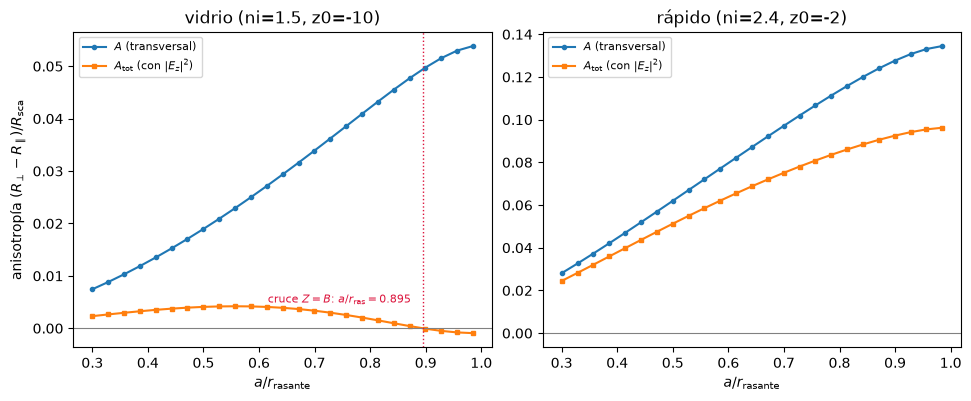

In [7]:
fracs = np.linspace(0.30, 0.985, 25)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9), constrained_layout=True)
for ax, (label, kw) in zip(axes, [("vidrio (ni=1.5, z0=-10)", dict(ni=1.5, z0=-10.0)),
                                  ("rápido (ni=2.4, z0=-2)", dict(ni=2.4, z0=-2.0))]):
    A_t, A_tot = [], []
    for f in fracs:
        cs = st.spot_case(n0=1.0, zi=6.0, lam=532e-6, a_frac=f, **kw)
        m = st.spot_metrics(cs)
        A_t.append(m["anisotropy"])
        A_tot.append(m["anisotropy_tot"])
    A_t, A_tot = np.array(A_t), np.array(A_tot)
    ax.plot(fracs, A_t, "o-", ms=3, label=r"$A$ (transversal)")
    ax.plot(fracs, A_tot, "s-", ms=3, label=r"$A_{\rm tot}$ (con $|E_z|^2$)")
    ax.axhline(0.0, color="gray", lw=0.8)
    if (A_tot < 0).any() and (A_tot > 0).any():
        f_c = float(np.interp(0.0, A_tot[::-1], fracs[::-1]))
        ax.axvline(f_c, color="crimson", ls=":", lw=1.0)
        ax.annotate(rf"cruce $Z=B$: $a/r_{{\rm ras}}={f_c:.3f}$",
                    (f_c, 0.0), xytext=(-8, 18), textcoords="offset points",
                    fontsize=8, color="crimson", ha="right")
    ax.set(title=label, xlabel=r"$a / r_{\rm rasante}$")
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"anisotropía $(R_\perp - R_\parallel)/R_{\rm sca}$")
fig.savefig(out_dir / "05_inversion.png", dpi=200)
plt.show()

## Conclusiones

1. El canal longitudinal admite la misma reducción radial que el resto del
   análisis: $E_z = -2\pi i\,\mathcal{H}_1[w_z t_p P]\cos(\varphi-\alpha)$,
   validada contra `vecdiff.longitudinal` al nivel de la FFT.
2. $I_\perp$ no cambia; $I_\parallel$ gana $4|H_z|^2$. La deformación total
   queda gobernada por el **balance local** $B-Z$ en $R_{\rm sca}$, con el
   predictor $A_{\rm tot}\simeq 4(B-Z)/(|I'_{\rm sca}|R_{\rm sca})$ (~5%).
3. Dos palancas independientes: $f_z$ la fija el ángulo de enfoque
   ($\sin\theta_{\max}=a/z_i$); $f_{\rm cross}$, el salto de índice. En el
   vidrio $f_z \approx 15\,f_{\rm cross}$: ignorar $E_z$ ahí es un error
   mayor que ignorar el canal cruzado.
4. La elongación se **invierte** (perpendicular $\to$ paralela, régimen de
   Richards–Wolf) en el cruce $Z=B$, que para el vidrio ocurre en
   $a/r_{\rm ras}\approx 0.9$. Más notable: en el vidrio los dos mecanismos
   se compensan en **todo** el barrido ($|A_{\rm tot}|\lesssim 0.004$): para
   dioptrios de bajo contraste el lóbulo total es redondo a cualquier
   apertura, aunque cada mecanismo por separado no sea despreciable.

**Referencias.** B. Richards, E. Wolf, *Electromagnetic diffraction in
optical systems II*, Proc. R. Soc. A **253**, 358 (1959); A. Boivin, E. Wolf,
*Electromagnetic field in the neighborhood of the focus of a coherent beam*,
Phys. Rev. **138**, B1561 (1965).